# 06 Commong Design Building Blocks
- Adding new activation functions
- Inserting new layers to improve training
- Skipping layers as a useful design pattern
- Combining new activations, layers and skips into new approaches
## Creating a baseline with the FashionMINST dataset for the improvements comparisons

In [1]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
#from idlmam import *
from sklearn.metrics import accuracy_score

In [3]:
# Import the dl_utils.py file
import sys, os

# Add the project root to the python path
sys.path.insert(0, os.path.abspath("../DL_utils_EZA")) # Goes up one level from current folder

# Autoreload: picks up edits to dl_utils.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# Import my own utilities
from dl_utils import * #import all my functions

print(" dl_utils loaded")

# Verification of CUDA present and force deterministic bahaviour for reproducibility with forced GPU usage

torch.backends.cudnn.benchmark = False  # False is better for RNNs with variable input sizes, True for CNNs

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device available: {device}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
 dl_utils loaded
Device available: cuda


In [4]:
# Load the Fashion-MNIST dataset
train_fmnist_data = torchvision.datasets.FashionMNIST("./data", train=True, transform=transforms.ToTensor(), download=False)
test_fmnist_data = torchvision.datasets.FashionMNIST("./data", train=False, transform=transforms.ToTensor(), download=False)

In [7]:
# Data loaders
train_fmnist_loader = DataLoader(train_fmnist_data, 
                                 batch_size=128, 
                                 shuffle=True,
                                 num_workers=4,
                                 pin_memory=True,
                                 persistent_workers=True,
                                 drop_last=True
)

test_fmnist_loader = DataLoader(test_fmnist_data, 
                                batch_size=128*2,
                                shuffle=False,
                                num_workers=4,
                                persistent_workers=True,
                                pin_memory=True
)

In [6]:
# Define the Hyperparameters for the baseline model
W = 28          # Width of the images from FashionMNIST
H = 28          # Height of the images from FashionMNIST
D = 28*28       # Number of values in the input. This value helps to determine size of subsequent layers: 28*28 images
n = 256         # Hidden layers size
C = 1           # Channels in the input
n_filters = 32  # Number of filters (kernels) per convolutional layer
classes = 10    # Number of clases in the data set

loss_function = nn.CrossEntropyLoss()

In [6]:
# Define a FULLY CONNECTED NETWORK baseline model
fc_model_base = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n), # First hidden layer
    nn.Tanh(),
    *[nn.Sequential(nn.Linear(n, n), nn.Tanh()) for _ in range(5)],  # "list unpacking", each reamining layer has the same
                                                                     # input/output sizes.
    nn.Linear(n, classes)
)

In [7]:
# Define the CNN baseline model
cnn_model_base = nn.Sequential(
    nn.Conv2d(C, n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d((2, 2)),
    nn.Conv2d(n_filters,2*n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Conv2d(2*n_filters,2*n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Conv2d(2*n_filters,2*n_filters, 3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d((2, 2)),
    nn.Conv2d(2*n_filters,4*n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Conv2d(4*n_filters,4*n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes)
)

In [ ]:
# Train the Fully Connected Network baseline
fc_model_base_results = train_network_EZA(fc_model_base,
                                          loss_function,
                                          train_fmnist_loader,
                                          test_loader=test_fmnist_loader,
                                          epochs=30,
                                          score_funcs={'Accuracy': accuracy_score},
                                          device=device
)

Epoch: 100%|██████████| 100/100 [05:09<00:00,  3.09s/it]


In [ ]:
# Train the CNN baseline

#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = True  # True for CNN training

# Train the Fully Connected Network baseline
cnn_model_base_results = train_network_EZA(cnn_model_base,
                                          loss_function,
                                          train_fmnist_loader,
                                          test_loader=test_fmnist_loader,
                                          epochs=30,
                                          score_funcs={'Accuracy': accuracy_score},
                                          device=device
)

Epoch: 100%|██████████| 100/100 [05:39<00:00,  3.40s/it]


(0.0, 30.0)

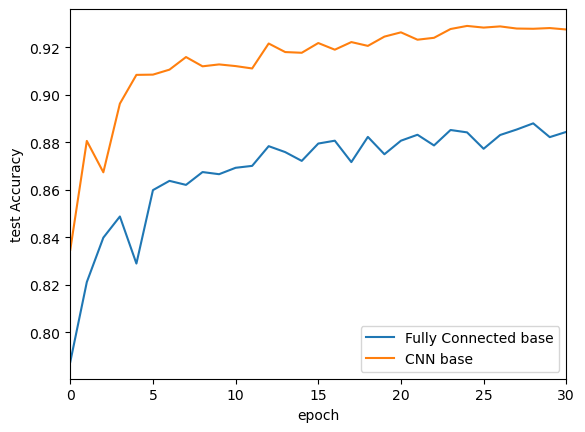

In [17]:
# 
# Plot the results for comparison
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_base_results, label='Fully Connected base')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_base_results, label='CNN base')
plt.xlim(0,30)

## Better Activation Functions
### Vanishing gradients problem of Tanh and sigmoid
When the gradient function gives values close to 0, giving no learing

<Axes: >

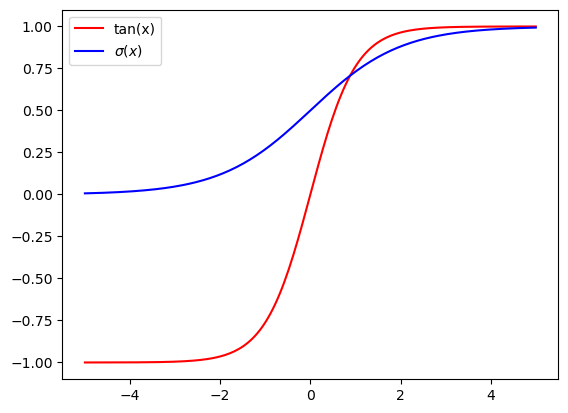

In [20]:
# Plot the sigmoid and Tanh functions
def sigmoid(x):
    return np.exp(activation_input)/(np.exp(activation_input)+1)

activation_input =  np.linspace(-5, 5, num=200)
tanh_activation = np.tanh(activation_input)
sigmoid_activation = sigmoid(activation_input)

sns.lineplot(x=activation_input, y=tanh_activation, color='red', label='tan(x)')
sns.lineplot(x=activation_input, y=sigmoid_activation, color='blue', label='$\sigma(x)$')

<Axes: >

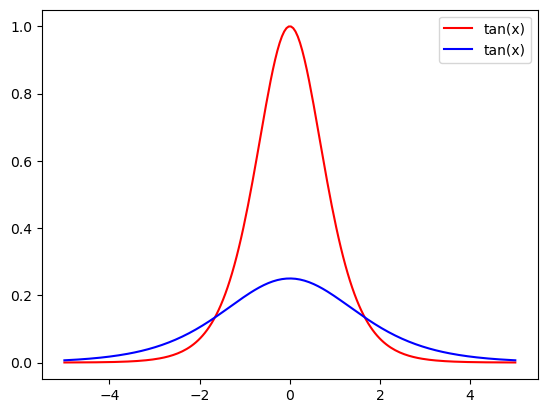

In [22]:
# Plot the derivatives of the Tanh and sigmoid fucntions to see the saturation effect
def tanh_deriv(x):
    return 1.0 - np.tanh(x)**2
def sigmoid_deriv(x):
    return sigmoid(x)*(1-sigmoid(x))

tanh_deriv = tanh_deriv(activation_input)
sigmoid_deriv = sigmoid_deriv(activation_input)

sns.lineplot(x=activation_input, y=tanh_deriv, color='red', label='tan(x)')
sns.lineplot(x=activation_input, y=sigmoid_deriv, color='blue', label='tan(x)')

### Avoiding Vanishing Gradients with: Rectified Linear Units (ReLU)
Definition:    $ReLU(x) = max(0,x)$\
Derivative: $ReLU'(x) = 1, if x > 0; 0, otherwise$

Another ReLU variation takes a factor alpha to avoid inactivation\
Definition:   $LeakyReLU(x) = max(\alpha*x,x)$\
Derivative:   $LeakyRELU'(x) = 1, if x > 0;  \alpha$, otherwise

(-1.2, 1.2)

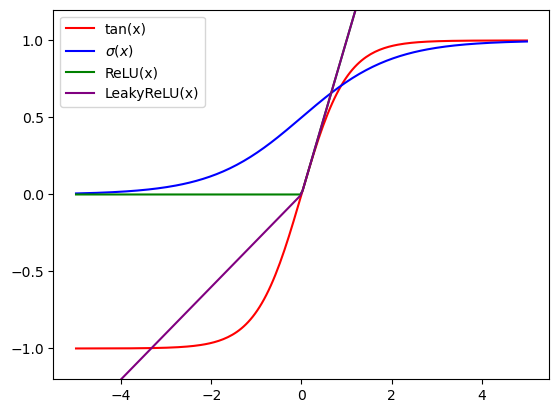

In [29]:
# ReLU and LeakyReLU plots
def leaky_relu(x, alpha=0.1):
    return max(alpha*x, x)
def leaky_reluP(x, alpha=0.1):
    if x > 0:
        return 1
    else:
        return alpha
    
relu_act = np.maximum(0, activation_input)
leaky_relu_act = np.maximum(0.3*activation_input, activation_input)

sns.lineplot(x=activation_input, y=tanh_activation, color='red', label='tan(x)')
sns.lineplot(x=activation_input, y=sigmoid_activation, color='blue', label='$\sigma(x)$')
sns.lineplot(x=activation_input, y=relu_act, color='green', label='ReLU(x)')
sns.lineplot(x=activation_input, y=leaky_relu_act, color='purple', label='LeakyReLU(x)')
plt.ylim(-1.2, 1.2)

<Axes: >

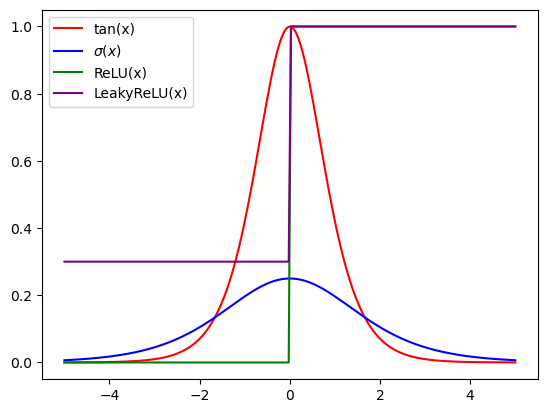

In [30]:
# Plot derivatives
relu_deriv = 1.0*(activation_input >0)
leaky_deriv = 1.0*(activation_input > 0) + 0.3*(activation_input <=0)

sns.lineplot(x=activation_input, y=tanh_deriv, color='red', label='tan(x)')
sns.lineplot(x=activation_input, y=sigmoid_deriv, color='blue', label='$\sigma(x)$')
sns.lineplot(x=activation_input, y=relu_deriv, color='green', label='ReLU(x)')
sns.lineplot(x=activation_input, y=leaky_deriv, color='purple', label='LeakyReLU(x)')

### Training with LeakyReLU activation

In [16]:
# Define the leak value
leak_rate = 0.1

# Define a FULLY CONNECTED NETWORK with LeakyReLU
fc_model_ReLU = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n), # First hidden layer
    nn.LeakyReLU(),
    *[nn.Sequential(nn.Linear(n, n), nn.LeakyReLU()) for _ in range(5)],  # "list unpacking", each reamining layer has the same
                                                                     # input/output sizes.
    nn.Linear(n, classes)
)

For THE CNN model we define a `cnnLayer` function ot croeate combinations of `Conv2d` to make changes easier

In [ ]:
def cnnLayer(in_filters, out_filters=None, kernel_size=3):
    """ 
    in_filters: Number of channels going into the layer
    out_filters: Number of channels this layer should learn / ouptut, or "None" if we want the same number of channels as the input
    kernel_size: Size of the kernel
    """
    if out_filters is None:
        out_filters = in_filters  # A common pattern, now automated
    padding = kernel_size//2  # Padding to stay the same size
    return nn.Sequential(
        nn.Conv2d(in_filters, out_filters, kernel_size, padding=padding),
        nn.LeakyReLU(leak_rate)
    ) 

In [17]:
# Create the CNN model with LeakyReLU
cnn_model_ReLU = nn.Sequential(
    nn.Conv2d(C, n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.MaxPool2d((2, 2)),
    nn.Conv2d(n_filters,2*n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(2*n_filters,2*n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(2*n_filters,2*n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.MaxPool2d((2, 2)),
    nn.Conv2d(2*n_filters,4*n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(4*n_filters,4*n_filters, 3, padding=1),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes)
)

In [18]:
# Train the fully connected network with reLU
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = False  # False for training FC

fc_model_ReLU_results = train_network_EZA(fc_model_ReLU,
                                          loss_function,
                                          train_fmnist_loader,
                                          test_loader=test_fmnist_loader,
                                          epochs=30,
                                          score_funcs={'Accuracy': accuracy_score},
                                          device=device
)

Epoch: 100%|██████████| 30/30 [01:48<00:00,  3.63s/it]


In [19]:
# Train the CNN with ReLU

#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = True  # True for CNN training

# Train the Fully Connected Network baseline
cnn_model_ReLU_results = train_network_EZA(cnn_model_ReLU,
                                          loss_function,
                                          train_fmnist_loader,
                                          test_loader=test_fmnist_loader,
                                          epochs=30,
                                          score_funcs={'Accuracy': accuracy_score},
                                          device=device
)

Epoch: 100%|██████████| 30/30 [02:06<00:00,  4.23s/it]


(0.0, 10.0)

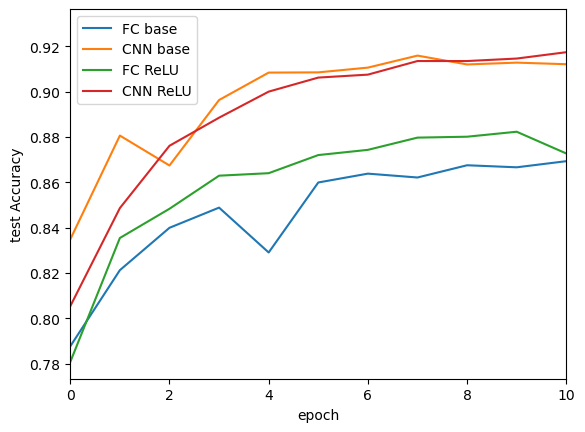

In [ ]:
# Plot results
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_base_results, label='FC base')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_base_results, label='CNN base')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_ReLU_results, label='FC ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_ReLU_results, label='CNN ReLU')
plt.xlim(0,30)


Try different batch sizes !!!!

## Normalization  layers: Better convergence
Before training the model it is a good practice to normalize the data. Many algorithms are sensitive to the scale of the input data.\
Also, it is better to normalize before every layer of the neural network.
There are two normalization layers widely use:
- batch
- layer
### Batch Normalization (BN)
It normalizes over the data features in a given **batch**

In [9]:
# Define the leak value
leak_rate = 0.1

# Batch normalization model
fc_bn_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n),
    nn.BatchNorm1d(n),
    nn.LeakyReLU(leak_rate),
    *[nn.Sequential(nn.Linear(n, n), nn.BatchNorm1d(n), nn.LeakyReLU(leak_rate)) for _ in range(5)],
    nn.Linear(n, classes)
)

In [11]:
# Define a CNN with a function for the model
def cnnLayer(in_filters, out_filters=None, kernel_size=3):
    """ 
    in_filters: Number of channels going into the layer
    out_filters: Number of channels this layer should learn / ouptut, or "None" if we want the same number of channels as the input
    kernel_size: Size of the kernel
    """
    if out_filters is None:
        out_filters = in_filters  # A common pattern, now automated
    padding = kernel_size//2  # Padding to stay the same size
    return nn.Sequential(
        nn.Conv2d(in_filters, out_filters, kernel_size, padding=padding),
        nn.BatchNorm2d(out_filters),
        nn.LeakyReLU(leak_rate)
    ) 

In [ ]:
# CNN batch normalization model
cnn_bn_model = nn.Sequential(
    cnnLayer(C, n_filters),
    cnnLayer(n_filters),
    cnnLayer(n_filters),
    nn.MaxPool2d((2, 2)),
    cnnLayer(n_filters, 2*n_filters),
    cnnLayer(2*n_filters),
    cnnLayer(2*n_filters),
    nn.MaxPool2d((2, 2)),
    cnnLayer(2*n_filters, 4*n_filters),
    cnnLayer(4*n_filters),
    cnnLayer(4*n_filters),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes)
)

In [13]:
# Train the fully connected with BN model
torch.backends.cudnn.benchmark = False  # False for training FC

fc_bn_model_results = train_network_EZA(fc_bn_model,
                                        loss_function,
                                        train_fmnist_loader,
                                        test_loader=test_fmnist_loader,
                                        epochs=30,
                                        score_funcs={'Accuracy': accuracy_score},
                                        device=device
)

Epoch: 100%|██████████| 30/30 [02:12<00:00,  4.43s/it]


In [15]:
# Train the CNN with BN

#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = True  # True for CNN training

cnn_bn_model_results = train_network_EZA(cnn_bn_model,
                        loss_function,
                        train_fmnist_loader,
                        test_loader=test_fmnist_loader,
                        epochs=30,
                        score_funcs={'Accuracy': accuracy_score},
                        device=device
)

Epoch: 100%|██████████| 30/30 [02:43<00:00,  5.45s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

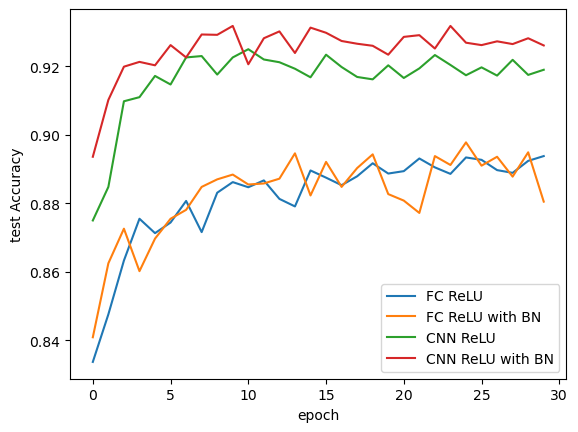

In [23]:
# Plot results
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_ReLU_results, label='FC ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_bn_model_results, label='FC ReLU with BN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_ReLU_results, label='CNN ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_bn_model_results, label='CNN ReLU with BN')


### Layer Normalization
Takes the average activation over features instead of over batches.

In [32]:
# The Layer Normalized model

fc_ln_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n),
    nn.LayerNorm([n]),
    nn.LeakyReLU(leak_rate),
    *[nn.Sequential(nn.Linear(n, n), nn.LayerNorm([n]), nn.LeakyReLU(leak_rate)) for _ in range(5)],
    nn.Linear(n, classes)
)

In [29]:
# CNN layer normalization
# Define a CNN with a function for the model
def cnnLayer2(in_filters, out_filters=None, pool_factor=0,  kernel_size=3):
    """ 
    in_filters: Number of channels going into the layer
    out_filters: Number of channels this layer should learn / ouptut, or "None" if we want the same number of channels as the input
    kernel_size: Size of the kernel
    """
    if out_filters is None:
        out_filters = in_filters  # A common pattern, now automated
    padding = kernel_size//2  # Padding to stay the same size
    return nn.Sequential(  # Combines the layer and activation into a single unit
        nn.Conv2d(in_filters, out_filters, kernel_size, padding=padding),
        nn.LayerNorm([out_filters, W//(2**pool_factor), H//(2**pool_factor)]),
        nn.LeakyReLU(leak_rate)
    ) 

In [30]:
# CNN layer normalization model
cnn_ln_model = nn.Sequential(
    cnnLayer2(C, n_filters),
    cnnLayer2(n_filters),
    cnnLayer2(n_filters),
    nn.MaxPool2d((2, 2)),
    cnnLayer2(n_filters, 2*n_filters, pool_factor=1),  # After 1 round pool_factor = 1
    cnnLayer2(2*n_filters, pool_factor=1),
    cnnLayer2(2*n_filters, pool_factor=1),
    nn.MaxPool2d((2, 2)),
    cnnLayer2(2*n_filters, 4*n_filters, pool_factor=2),   # After 2 rounds pool_factor = 2
    cnnLayer2(4*n_filters, pool_factor=2),
    cnnLayer2(4*n_filters, pool_factor=2),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes)
)

In [33]:
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

# Train the fully connected with LN model
torch.backends.cudnn.benchmark = False  # False for training FC

fc_ln_model_results = train_network_EZA(fc_ln_model,
                                        loss_function,
                                        train_fmnist_loader,
                                        test_loader=test_fmnist_loader,
                                        epochs=30,
                                        score_funcs={'Accuracy': accuracy_score},
                                        device=device
)

Epoch: 100%|██████████| 30/30 [01:52<00:00,  3.76s/it]


In [34]:
# Train the CNN with LN

#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = True  # True for CNN training

cnn_ln_model_results = train_network_EZA(cnn_ln_model,
                        loss_function,
                        train_fmnist_loader,
                        test_loader=test_fmnist_loader,
                        epochs=30,
                        score_funcs={'Accuracy': accuracy_score},
                        device=device
)

Epoch: 100%|██████████| 30/30 [02:32<00:00,  5.08s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

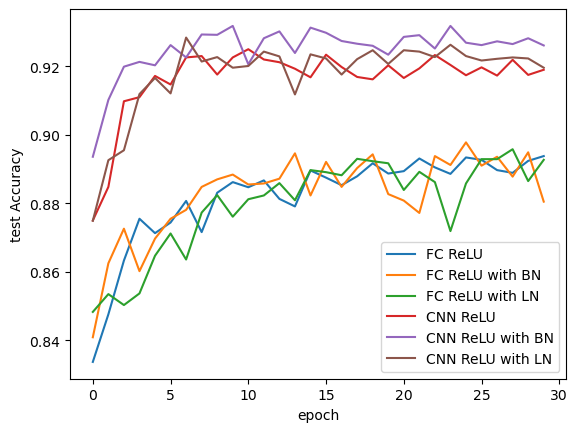

In [35]:
# Plot results
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_ReLU_results, label='FC ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_bn_model_results, label='FC ReLU with BN')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_ln_model_results, label='FC ReLU with LN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_ReLU_results, label='CNN ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_bn_model_results, label='CNN ReLU with BN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_ln_model_results, label='CNN ReLU with LN')

## Skip connections: A network design pattern